<h1> CMBI Coursework 2 - Part 1
<h3> Giuliano Costa

In [66]:
"""Imports"""
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

In [67]:
random_seed = 24225233

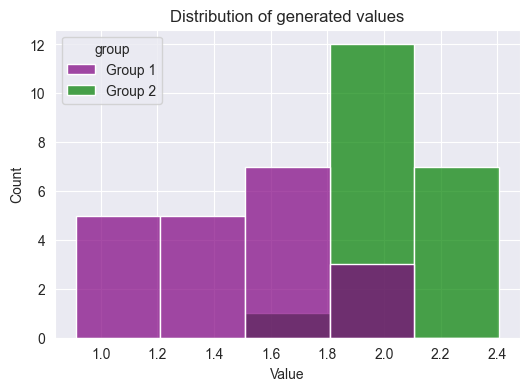

In [68]:
samples_1 = stats.norm.rvs(loc=1.5, scale=0.2, random_state=random_seed, size=20)
samples_2 = stats.norm.rvs(loc=2.0, scale=0.2, random_state=random_seed+1, size=20)

df = pd.DataFrame({
    'value': np.concatenate([samples_1, samples_2]),
    'group': ['Group 1'] * len(samples_1) + ['Group 2'] * len(samples_2)
})

plt.figure(figsize=(6, 4))
sns.set_style('darkgrid')
ax = sns.histplot(data=df, bins=5, x='value', hue='group', palette={'Group 1': 'purple', 'Group 2': 'green'}, alpha=0.7)
ax.set(title="Distribution of generated values", xlabel='Value', ylabel='Count')
plt.show()



# 1 Two Sample CI

## 1.a Calculate Mean and Std

In [69]:
mean_1 = np.sum(samples_1) / 20
mean_2 = np.sum(samples_2) / 20
std_1 = np.std(samples_1)
std_2 = np.std(samples_2)
print("Grp 1 Mean: %.4f" % mean_1, "Grp 1 std: %.4f" % std_1)
print("Grp 2 Mean: %.4f" % mean_2, "Grp 2 std: %.4f" % std_2)

Grp 1 Mean: 1.4850 Grp 1 std: 0.2677
Grp 2 Mean: 2.0303 Grp 2 std: 0.1840


## 1.b Compute two-sample t-statistic using ttest2

In [70]:
test_stat, pvalue =  stats.ttest_ind(samples_1, samples_2, random_state=random_seed, equal_var=True)
print("t-stat %.10f" % test_stat)
print("p-value %.10f" % pvalue)
print("p-value %.2e" % pvalue)


t-stat -7.3178286416
p-value 0.0000000092
p-value 9.17e-09


## 1.c Compute two-sample t-statistic using GLM

### i Derive Design matrix $X$

Where $Y = X_1 B_1 + X_2 B_2 + e $

And $ X = [X_1  X_2] $


Then the dimension of the column space $C(X)$ would be $2$

In [71]:
"""Derive the design matrix"""
X = np.zeros((40, 2))
X[:20, 0] = 1
X[20:, 1] = 1
X

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [72]:
print("dim(X): ", X.shape[1])

dim(X):  2


### ii Derive general formula

$P_x = X(X^{\intercal}X)^{-1}X^{\intercal}$



In [73]:
Px = X @ np.linalg.inv(X.T @ X) @ X.T
Px

array([[0.05, 0.05, 0.05, ..., 0.  , 0.  , 0.  ],
       [0.05, 0.05, 0.05, ..., 0.  , 0.  , 0.  ],
       [0.05, 0.05, 0.05, ..., 0.  , 0.  , 0.  ],
       ...,
       [0.  , 0.  , 0.  , ..., 0.05, 0.05, 0.05],
       [0.  , 0.  , 0.  , ..., 0.05, 0.05, 0.05],
       [0.  , 0.  , 0.  , ..., 0.05, 0.05, 0.05]])

In [74]:
"""dim(C(X)) = rank(X) = tr(Px)"""
print("tr(Px)", np.trace(Px))

tr(Px) 2.0


### iii Determine $\hat{Y}$

In [75]:
Y = np.concatenate((samples_1, samples_2))
Y

array([1.41375869, 1.79246329, 1.44117927, 0.91265544, 1.20954837,
       1.60565228, 1.49827248, 1.20068758, 1.01593769, 1.64611097,
       1.8367004 , 1.15433193, 1.84331116, 1.36431529, 1.5683697 ,
       1.71372067, 1.84265076, 1.63305043, 1.48442323, 1.52244036,
       1.86868745, 2.07823894, 1.98055579, 1.89140428, 1.85236527,
       2.17485681, 1.72514909, 1.94655957, 1.88475061, 1.97542572,
       2.13013345, 2.01529366, 2.40253282, 2.11623673, 2.01110055,
       2.178345  , 1.81009418, 1.88210558, 2.27695166, 2.40481446])

In [76]:
"""Y hat is the predicted Y values"""
Y_hat = Px @ Y
Y_hat

array([1.484979  , 1.484979  , 1.484979  , 1.484979  , 1.484979  ,
       1.484979  , 1.484979  , 1.484979  , 1.484979  , 1.484979  ,
       1.484979  , 1.484979  , 1.484979  , 1.484979  , 1.484979  ,
       1.484979  , 1.484979  , 1.484979  , 1.484979  , 1.484979  ,
       2.03028008, 2.03028008, 2.03028008, 2.03028008, 2.03028008,
       2.03028008, 2.03028008, 2.03028008, 2.03028008, 2.03028008,
       2.03028008, 2.03028008, 2.03028008, 2.03028008, 2.03028008,
       2.03028008, 2.03028008, 2.03028008, 2.03028008, 2.03028008])

### iv Compute $R_x$

In [77]:
Rx = np.eye(Px.shape[0]) - Px
Rx

array([[ 0.95, -0.05, -0.05, ...,  0.  ,  0.  ,  0.  ],
       [-0.05,  0.95, -0.05, ...,  0.  ,  0.  ,  0.  ],
       [-0.05, -0.05,  0.95, ...,  0.  ,  0.  ,  0.  ],
       ...,
       [ 0.  ,  0.  ,  0.  , ...,  0.95, -0.05, -0.05],
       [ 0.  ,  0.  ,  0.  , ..., -0.05,  0.95, -0.05],
       [ 0.  ,  0.  ,  0.  , ..., -0.05, -0.05,  0.95]])

In [78]:
"""Is Rx idempotent?"""
print("Rx idempotent: ", np.allclose(Rx @ Rx, Rx))
"""Is Rx symmetric?"""
print("Rx symmetric: ", np.allclose(Rx.T, Rx))


Rx idempotent:  True
Rx symmetric:  True


### v. Compute $R_x$

In [79]:
e_hat = Rx @ Y
e_hat

array([-7.12203092e-02,  3.07484287e-01, -4.37997306e-02, -5.72323563e-01,
       -2.75430631e-01,  1.20673280e-01,  1.32934766e-02, -2.84291417e-01,
       -4.69041306e-01,  1.61131971e-01,  3.51721403e-01, -3.30647072e-01,
        3.58332163e-01, -1.20663712e-01,  8.33906972e-02,  2.28741670e-01,
        3.57671764e-01,  1.48071432e-01, -5.55764912e-04,  3.74613609e-02,
       -1.61592633e-01,  4.79588643e-02, -4.97242921e-02, -1.38875804e-01,
       -1.77914806e-01,  1.44576728e-01, -3.05130987e-01, -8.37205144e-02,
       -1.45529470e-01, -5.48543636e-02,  9.98533650e-02, -1.49864170e-02,
        3.72252743e-01,  8.59566480e-02, -1.91795304e-02,  1.48064918e-01,
       -2.20185899e-01, -1.48174504e-01,  2.46671578e-01,  3.74534377e-01])

In [80]:
dim_C_perpendicular = 40 - X.shape[1]
dim_C_perpendicular

38

### vi. Determine the angle between e_hat and Y_hat

In [81]:
dot_product = Y_hat @ e_hat

# Calculate the norms
norm_Y_hat = np.linalg.norm(Y_hat)
norm_e_hat = np.linalg.norm(e_hat)

cos_angle = dot_product / (norm_Y_hat * norm_e_hat)

angle_degrees = np.arccos(np.clip(cos_angle, -1.0, 1.0)) * 180 / np.pi

print(f"Dot product: {dot_product}")
print(f"Cosine of angle: {cos_angle}")
print(f"Angle between Y_hat and e_hat: {angle_degrees} degrees")
print(f"Are they orthogonal? {np.allclose(dot_product, 0, atol=1e-10)}")

Dot product: -1.476815012826083e-14
Cosine of angle: -9.037730841061195e-16
Angle between Y_hat and e_hat: 90.00000000000006 degrees
Are they orthogonal? True


### vii. general formula for estimating model parameters.

In [82]:
XTX = X.T @ X
XTX_inv = np.linalg.inv(XTX)
XTY = X.T @ Y
beta_hat = XTX_inv @ XTY

print("Design matrix X:")
print(X[:5]) 

print("\nX'X:")
print(XTX)

print("\n(X'X)⁻¹:")
print(XTX_inv)

print("\nX'Y:")
print(XTY)

print("\nEstimated parameters β̂:")
print(beta_hat)

print("\nGroup means:")
print(f"Group 1 mean: {np.mean(Y[:20])}")
print(f"Group 2 mean: {np.mean(Y[20:])}")

Design matrix X:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]

X'X:
[[20.  0.]
 [ 0. 20.]]

(X'X)⁻¹:
[[0.05 0.  ]
 [0.   0.05]]

X'Y:
[29.69957997 40.60560161]

Estimated parameters β̂:
[1.484979   2.03028008]

Group means:
Group 1 mean: 1.4849789986011837
Group 2 mean: 2.030280080555807


### viii. Estimate the variance of the stochastic component

In [83]:
n = X.shape[0]  # Total number of observations
dim_X = np.linalg.matrix_rank(X) 
sigma_squared_hat = (e_hat.T @ e_hat) / (n - dim_X)

print(f"Estimated error variance (σ̂²): {sigma_squared_hat}")

Estimated error variance (σ̂²): 0.05552751621548851


### ix. Estimate the the covariance matrix

In [84]:
S_beta = sigma_squared_hat * XTX_inv

print("Covariance matrix of β̂:")
print(S_beta)

std_beta = np.sqrt(np.diag(S_beta))

print("\nStandard deviations of model parameters:")
print(f"SD of β̂₁: {std_beta[0]}")
print(f"SD of β̂₂: {std_beta[1]}")

Covariance matrix of β̂:
[[0.00277638 0.        ]
 [0.         0.00277638]]

Standard deviations of model parameters:
SD of β̂₁: 0.052691325764061256
SD of β̂₂: 0.052691325764061256


### x. Derive the appropriate contrast vector $\lambda$

In [85]:
"""Null hypothesis that both groups of samples have the same expected value"""
"""lambda ^ T * beta = 0 """
LAMBDA = np.array([1, -1]) #NOTE: Literally don't use this, just for exposition.
print(LAMBDA)
X_0 = np.ones((40, 1)) 
X_0

[ 1 -1]


array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

### xi. Compute the F-Statistic by comparing the Sum of Squared Residuals between the Reduced Model and the Full Model

In [86]:
"""Use our new reduced model to compute the additional error"""
X0TX0 = X_0.T @ X_0
X0TX0_inv = np.linalg.inv(X0TX0)
P_X0 = X_0 @ X0TX0_inv @ X_0.T
R_X0 = np.eye(X_0.shape[0]) - P_X0

In [87]:
"""Estimate F-Statistic by comparing the reduced and full model"""

"""F_v1,v_2 = ((SSR(X_0) - SSR(X)) / v_1) / ( SSR(X) / v_2 )"""


SSE_full = (Rx @ Y).T @ (Rx @ Y)  
SSE_reduced = (R_X0 @ Y).T @ (R_X0 @ Y) 
SSE_diff = SSE_reduced - SSE_full

df_full = n - dim_X  # n - rank(X)
df_reduced = n - np.linalg.matrix_rank(X_0)  # n - rank(X₀)
df_diff = df_reduced - df_full 

F_stat = (SSE_diff / df_diff) / (SSE_full / df_full)

print(f"Error sum of squares (full model): {SSE_full}")
print(f"Error sum of squares (reduced model): {SSE_reduced}")
print(f"Additional error due to constraint: {SSE_diff}")
print(f"Degrees of freedom (full model): {df_full}")
print(f"Degrees of freedom (reduced model): {df_reduced}")
print(f"Degrees of freedom (difference): {df_diff}")
print(f"F-statistic: {F_stat}")

Error sum of squares (full model): 2.1100456161885632
Error sum of squares (reduced model): 5.08357831599739
Additional error due to constraint: 2.973532699808827
Degrees of freedom (full model): 38
Degrees of freedom (reduced model): 39
Degrees of freedom (difference): 1
F-statistic: 53.550616027363525


In [88]:
((SSE_reduced - SSE_full) / df_diff) / (SSE_full / df_full)

np.float64(53.550616027363525)

### xii. T-statistic

In [89]:
lambda_beta = LAMBDA @ beta_hat
lambda_S_lambda = LAMBDA @ S_beta @ LAMBDA
t_stat = lambda_beta / np.sqrt(lambda_S_lambda)

print(f"Contrast λ'β̂ (difference in means): {lambda_beta}")
print(f"Square root of λ'Sβ̂λ (SE of difference): {np.sqrt(lambda_S_lambda)}")
print(f"t-statistic: {t_stat}")

Contrast λ'β̂ (difference in means): -0.5453010819546233
Square root of λ'Sβ̂λ (SE of difference): 0.07451678751495432
t-statistic: -7.317828641568723


### xiii. Explain the meaning of model parameters

### xiv. Compute the projection of the ground truth deviation e into C(X)

In [90]:
beta_true = np.array([1.5, 2.0])  # True means 
e_true = Y - X @ beta_true
P_X = X @ XTX_inv @ X.T
e_proj_into_CX = P_X @ e_true

print("Projection of ground truth error e into C(X):")
print(e_proj_into_CX[:5])  # Show first few elements
print(f"Sum of squared projection: {e_proj_into_CX.T @ e_proj_into_CX}")

Projection of ground truth error e into C(X):
[-0.015021 -0.015021 -0.015021 -0.015021 -0.015021]
Sum of squared projection: 0.022850275229788195


In [91]:
e_true

array([-0.08624131,  0.29246329, -0.05882073, -0.58734456, -0.29045163,
        0.10565228, -0.00172752, -0.29931242, -0.48406231,  0.14611097,
        0.3367004 , -0.34566807,  0.34331116, -0.13568471,  0.0683697 ,
        0.21372067,  0.34265076,  0.13305043, -0.01557677,  0.02244036,
       -0.13131255,  0.07823894, -0.01944421, -0.10859572, -0.14763473,
        0.17485681, -0.27485091, -0.05344043, -0.11524939, -0.02457428,
        0.13013345,  0.01529366,  0.40253282,  0.11623673,  0.01110055,
        0.178345  , -0.18990582, -0.11789442,  0.27695166,  0.40481446])

### xv. Compute  projection of ground truth deviation

In [92]:
R_X = np.eye(X.shape[0]) - P_X
e_proj_into_CX_perp = R_X @ e_true
e_hat = R_X @ Y

print("Projection of ground truth error e into C(X)⊥:")
print(e_proj_into_CX_perp[:5]) 

print("\nEstimated error e_hat:")
print(e_hat[:5]) 
# Compare the two
difference = e_proj_into_CX_perp - e_hat
print("\nDifference between e projected into C(X)⊥ and e_hat:")
print(difference[:5])
print(f"Sum of squared differences: {difference.T @ difference}")

Projection of ground truth error e into C(X)⊥:
[-0.07122031  0.30748429 -0.04379973 -0.57232356 -0.27543063]

Estimated error e_hat:
[-0.07122031  0.30748429 -0.04379973 -0.57232356 -0.27543063]

Difference between e projected into C(X)⊥ and e_hat:
[3.60822483e-16 1.11022302e-16 2.35922393e-16 3.33066907e-16
 3.33066907e-16]
Sum of squared differences: 2.6767838258619808e-30


## 1.d Compute t-statistic with a different model

Change the model to $Y=X_0 \beta_0 + X_1 \beta_1 + e $
One group will now be the baseline or reference group, and the other can be used to measure deviation from the first group.

### i. Write down the design matrix and determine its column space

In [93]:
X = np.zeros(shape=(Y.shape[0], 3))
X[:,0] = 1
X[:20,1] = 1
X[20:,2] = 1
print(X[0:5])
print("dim(X)=" , np.linalg.matrix_rank(X))

[[1. 1. 0.]
 [1. 1. 0.]
 [1. 1. 0.]
 [1. 1. 0.]
 [1. 1. 0.]]
dim(X)= 2


### ii. compute the corresponding P_X

In [94]:
P_X = X @ np.linalg.pinv(X.T @ X) @ X.T
P_X

array([[5.00000000e-02, 5.00000000e-02, 5.00000000e-02, ...,
        3.46944695e-18, 3.46944695e-18, 3.46944695e-18],
       [5.00000000e-02, 5.00000000e-02, 5.00000000e-02, ...,
        3.46944695e-18, 3.46944695e-18, 3.46944695e-18],
       [5.00000000e-02, 5.00000000e-02, 5.00000000e-02, ...,
        3.46944695e-18, 3.46944695e-18, 3.46944695e-18],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        5.00000000e-02, 5.00000000e-02, 5.00000000e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        5.00000000e-02, 5.00000000e-02, 5.00000000e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        5.00000000e-02, 5.00000000e-02, 5.00000000e-02]])

### iii. Determine lambda

In [95]:
LAMBDA_INTERCEPT = np.asarray([0,1,-1]).reshape((1,-1))
constraint = np.asarray([[1, 0],
                   [0, 1],
                   [0, 1]])
X_0_intercept = X @ constraint
X_0_intercept.shape

(40, 2)

### iv. Determine the t-statistic

In [96]:
RX_INTERCEPT = (np.identity(Y.shape[0]) - P_X)
error_hat_intercept = RX_INTERCEPT @ Y
M = np.linalg.pinv(X.T @ X)
beta_intercept = M @ X.T @ Y

var_hat_intercept = (np.dot(error_hat_intercept, error_hat_intercept)) / (Y.shape[0] - np.linalg.matrix_rank(X))

S_beta_intercept = var_hat_intercept * M

numerator = LAMBDA_INTERCEPT @ beta_intercept
denominator = np.sqrt(LAMBDA_INTERCEPT @ S_beta_intercept @ LAMBDA_INTERCEPT.T)
t_statistic_intercept = (numerator / denominator)[0,0]
t_statistic_intercept

np.float64(-7.317828641568722)

## 1.e Compute with $Y = X_0B_0 + X_1B_1 + e $

### i.

In [97]:
X =  np.zeros(shape=(Y.shape[0], 2))
X[:,   0] = 1
X[:20, 1] = 1

print(f"Dim(X) {np.linalg.matrix_rank(X)}")

Dim(X) 2


### ii.

In [98]:
LAMBDA_SIMPLE = np.array([0, 1]).reshape((2, -1))
LAMBDA_SIMPLE

array([[0],
       [1]])

### iii.

In [99]:
P_X_SIMPLE = X @ np.linalg.pinv(X.T @ X) @ X.T
print(P_X_SIMPLE)

d = Y.shape[0]
Rx_e = (np.identity(d) - P_X_SIMPLE)
error_hat_e = Rx_e @ Y
M = np.linalg.pinv(X.T @ X)
beta_e = M @ X.T @ Y

var_hat_e = (error_hat_e @ error_hat_e) / (d - np.linalg.matrix_rank(X))
S_beta_e = var_hat_e * M

numerator = LAMBDA_SIMPLE.flatten() @ beta_e
denominator = np.sqrt(LAMBDA_SIMPLE.T @ S_beta_e @ LAMBDA_SIMPLE)
T_STATISTIC_SIMPLE = (numerator / denominator)[0,0]
print("\nt-statistic for simple model" , T_STATISTIC_SIMPLE)

[[ 5.00000000e-02  5.00000000e-02  5.00000000e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 5.00000000e-02  5.00000000e-02  5.00000000e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 5.00000000e-02  5.00000000e-02  5.00000000e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [-1.38777878e-17 -1.38777878e-17 -1.38777878e-17 ...  5.00000000e-02
   5.00000000e-02  5.00000000e-02]
 [-1.38777878e-17 -1.38777878e-17 -1.38777878e-17 ...  5.00000000e-02
   5.00000000e-02  5.00000000e-02]
 [-1.38777878e-17 -1.38777878e-17 -1.38777878e-17 ...  5.00000000e-02
   5.00000000e-02  5.00000000e-02]]

t-statistic for simple model -7.317828641568714


## 1.f test same hypothesis for even simpler model $ Y = X_0 \beta_0 + e $

For the simplest model Y = X₀β₀ + e, we're essentially removing all group-specific effects and fitting just an intercept. This model assumes that all observations come from the same population with the same mean β₀.

In [100]:
X_simplest = np.ones((20 + 20, 1))

# least squares estimate
X_simplest_T = X_simplest.T
X_simplest_TX_simplest = X_simplest_T @ X_simplest
X_simplest_TX_simplest_inv = np.linalg.inv(X_simplest_TX_simplest)
X_simplest_TY = X_simplest_T @ Y
beta_hat_simplest = X_simplest_TX_simplest_inv @ X_simplest_TY

print("Simplest design matrix X:")
print(X_simplest[:5]) 

print("\nEstimated parameter β_std (overall mean):")
print(f"β_std: {beta_hat_simplest[0]}")

# Calculate the residuals and error variance
P_X_simplest = X_simplest @ X_simplest_TX_simplest_inv @ X_simplest_T
R_X_simplest = np.eye(X_simplest.shape[0]) - P_X_simplest
e_hat_simplest = R_X_simplest @ Y
sigma_squared_hat_simplest = (e_hat_simplest.T @ e_hat_simplest) / (n - X_simplest.shape[1])

Simplest design matrix X:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]]

Estimated parameter β_std (overall mean):
β_std: 1.7576295395784962


# 2. Paired t-test for comparing means

You're using the same random seed for both samples. When you create random numbers with the same seed, NumPy/SciPy will generate the exact same sequence of random numbers.
This means your samples_1 and samples_2 are actually the same random sequence, just with different means added. When you calculate the differences between pairs, you get a perfect constant difference of 0.5 with zero variance, which is causing the extremely large t-statistic.

### a. Repeat Observations

In [101]:
test_stat_1_sample, p_val_1_sample = stats.ttest_rel(samples_1, samples_2)
print(f"t-test for 1 sample dist.: t = {test_stat_1_sample:.2f}, p-value = {p_val_1_sample:2e}")
print(f"t-test for 2 sample dist.: t = {test_stat:.2f}, p-value = {pvalue:2e}")

t-test for 1 sample dist.: t = -9.03, p-value = 2.653609e-08
t-test for 2 sample dist.: t = -7.32, p-value = 9.174000e-09


### b. Paired GLM

$Y = X_0\beta_0 + X_1\beta_1 + \sum_{i=1}^{N} S_i s_i + e $

### i. determine design matrix

In [ ]:
n_subjects = 20  
n_total = len(Y)  
X0 = np.ones(n_total)

X1 = np.zeros(n_total)
X1[20:] = 1  # Second half

S = np.zeros((n_total, n_subjects))
for i in range(n_subjects):
    S[i, i] = 1      # First observation of subject i
    S[i+20, i] = 1   # Second observation of subject i

X = np.column_stack([X0, X1, S])

X[0:5]

array([[1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.]])

In [103]:
np.linalg.matrix_rank(X)

np.int64(21)

### ii. Write down the appropriate contrast vector λ.

In [104]:
lambda_vec = np.zeros(X.shape[1])
lambda_vec[1] = 1

### iii. Compute the t-statistic. (Is your answer identical to that in (a)?)

In [105]:
XTX = X.T @ X
XTX_inv = np.linalg.pinv(XTX) 
XTY = X.T @ Y
beta_hat = XTX_inv @ XTY

P_X = X @ XTX_inv @ X.T
R_X = np.eye(n_total) - P_X
e_hat = R_X @ Y 
sigma_squared_hat = (e_hat.T @ e_hat) / (n_total - np.linalg.matrix_rank(X))

S_beta = sigma_squared_hat * XTX_inv

lambda_beta = lambda_vec @ beta_hat
lambda_S_lambda = lambda_vec @ S_beta @ lambda_vec
t_stat = lambda_beta / np.sqrt(lambda_S_lambda)

print(f"Parameter estimate for β₁ (time effect): {beta_hat[1]:.6f}")
print(f"t-statistic from GLM: {t_stat:.6f}")

scipy_t_stat, scipy_p_value = stats.ttest_rel(samples_1, samples_2)
print(f"t-statistic from scipy.stats.ttest_rel: {scipy_t_stat:.6f}")

Parameter estimate for β₁ (time effect): 0.545301
t-statistic from GLM: 9.029595
t-statistic from scipy.stats.ttest_rel: -9.029595
